In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
allclusters = pd.read_pickle("/Users/user/data/research/proton-deuteron/csv/allclusters.pkl")
allclusters = allclusters[allclusters['height'] > 2]

In [ ]:
allclusters = pd.read_pickle("/Users/user/data/research/proton-deuteron/csv/allclusters.pkl")
masses = pd.read_csv('/Users/user/data/research/proton-deuteron/csv/picky+match.csv')


HANDPICKED = '/Users/user/data/research/proton-deuteron/ssvd/handpicked_d.pkl'
CANDIDATES = '/Users/user/data/research/proton-deuteron/ssvd/deuteron_candidates_clean.pkl'
PROTONS = '/Users/user/data/research/proton-deuteron/ssvd/proton_candidates.pkl'

h = pd.read_pickle(HANDPICKED)
c = pd.read_pickle(CANDIDATES)
p = pd.read_pickle(PROTONS)

all = pd.concat([h, c, p], ignore_index=True)

BETHE = '/Users/user/data/research/proton-deuteron/protons.txt'

bethe_data = np.loadtxt(BETHE)
resrange = bethe_data[:, 0]
bb = bethe_data[:, 1]
resrange = np.flip(resrange)
resrange = resrange*1.9

In [119]:
sumADC = [np.sum(cluster, axis=1)[:-1] for cluster in p['image_intensity'].values]
p = p.copy()
p['energy'] = sumADC
residual_range = [list(range(len(cluster)-1, -1, -1)) for cluster in p['energy'].values]
p['rr'] = residual_range

e_diff = [np.diff(np.sum(cluster, axis=1)[:-1]) for cluster in p['image_intensity'].values]
p['e_diff'] = e_diff
rr_diff = [list(range(len(cluster)-1, -1, -1)) for cluster in p['e_diff'].values]
p['rr_diff'] = rr_diff

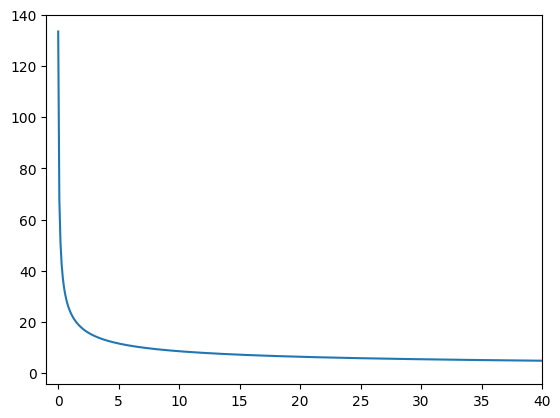

((-1.0, 40.0), None)

In [101]:
plt.plot(resrange, bb); plt.xlim(-1, 40), plt.show()

In [91]:
wirerr = resrange * (100 / 47)

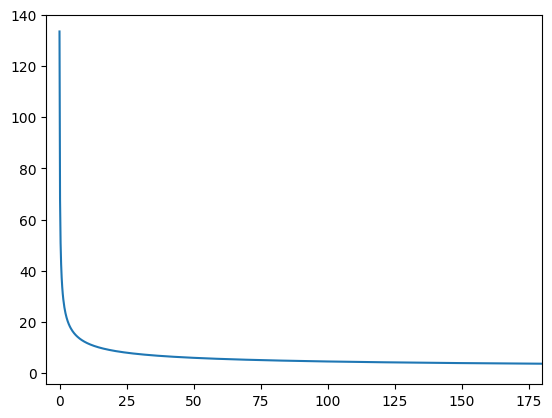

In [99]:
plt.plot(wirerr, bb); plt.xlim(-5, 180); plt.show()

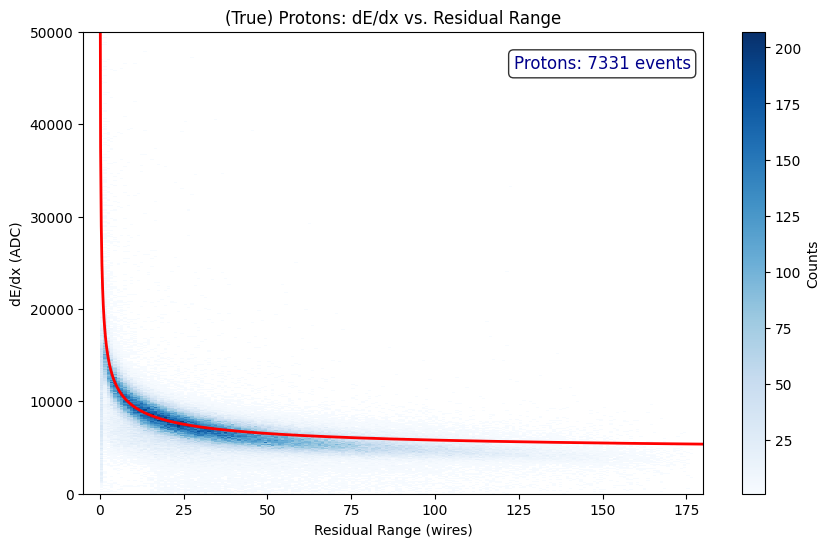

In [151]:
# Concatenate proton data
rr_protons = np.concatenate(p['rr'].values)
energy_protons = np.concatenate(p['energy'].values)

# Plot for protons
plt.figure(figsize=(10, 6))
plt.hist2d(rr_protons, energy_protons, bins=(177, 2000), cmap='Blues', cmin=1)
plt.plot(wirerr, (bb)*500 + 3500, linewidth=2, color='red', label='Bethe-Bloch mean')
plt.colorbar(label='Counts')
plt.xlabel('Residual Range (wires)')
plt.ylabel('dE/dx (ADC)')
plt.ylim(0, 50000)
plt.xlim(-5, 180)
plt.title('(True) Protons: dE/dx vs. Residual Range')
plt.text(0.98, 0.95, f'Protons: {len(p)} events', 
         transform=plt.gca().transAxes, fontsize=12, color='darkblue',
         ha='right', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.show()

In [ ]:
# TODO: ASK ELENA: (bb)*500 + 3500
# TODO: COMPARE W/ PROTONS
# TODO: DEUTERON BETHE-BLOCH MODEL
# TODO: COMPARE W/ DUETERONS
# TODO: SCIPY MINIMISE
# TODO: HUBER FIT - scikit learn

In [33]:
all = pd.merge(
    all,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

In [43]:
sumADC = [np.sum(cluster, axis=1)[:-1] for cluster in all['image_intensity'].values]
all = all.copy()
all['energy'] = sumADC
residual_range = [list(range(len(cluster)-1, -1, -1)) for cluster in all['energy'].values]
all['rr'] = residual_range

In [73]:
from scipy.interpolate import interp1d

interpolator = interp1d(resrange, bb, bounds_error=False, fill_value="extrapolate")

sum_of_squares = []
for energy, rr in zip(all['energy'], all['rr']):
    interpolated_bb = interpolator(rr)
    squared_diff = (energy - interpolated_bb) ** 2
    rms_diff = np.sqrt(np.mean(squared_diff))
    sum_of_squares.append(np.sum(rms_diff))

all['sum_of_squares'] = sum_of_squares

In [ ]:
sum_of_squares = []
for energy, rr in zip(all['energy'], all['rr']):
    valid_indices = (rr >= resrange.min()) & (rr <= resrange.max())
    rr_valid = np.array(rr)[valid_indices]
    energy_valid = np.array(energy)[valid_indices]
    
    closest_indices = np.searchsorted(resrange, rr_valid, side='left')
    closest_indices = np.clip(closest_indices, 0, len(resrange) - 1)

    bb_values = bb[closest_indices]

    squared_diff = (energy_valid - bb_values) ** 2
    rms_diff = np.sqrt(np.mean(squared_diff)) 
    sum_of_squares.append(np.sum(rms_diff))

all['sum_of_squares'] = sum_of_squares

In [74]:
all['sum_of_squares']

0        11470.378794
1        10288.054916
2         8651.385597
3         7435.836931
4         8973.838359
             ...     
12386     5572.355833
12387     4458.982462
12388     3183.970092
12389     5609.337051
12390     4291.065445
Name: sum_of_squares, Length: 12391, dtype: float64

(-1000.0, 20000.0)

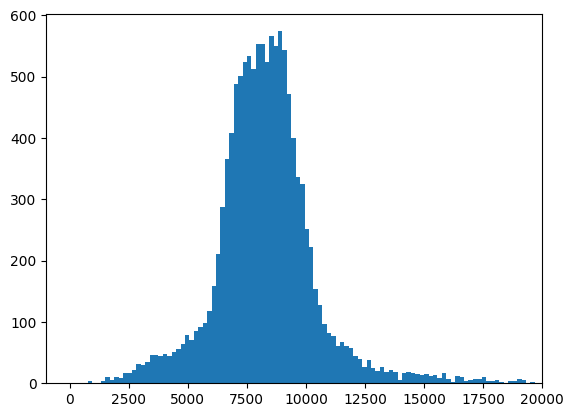

In [75]:
plt.hist(all['sum_of_squares'], bins='auto')
plt.xlim(-1000, 20000)

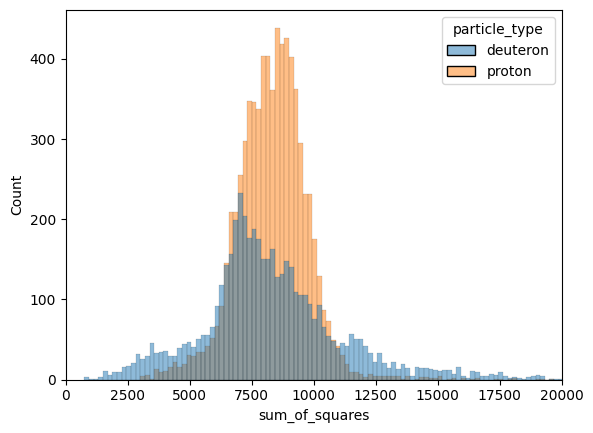

In [76]:
sns.histplot(data=all, x='sum_of_squares', hue='particle_type')
plt.xlim(0, 20000)
plt.show()

In [55]:
allclusters = allclusters[allclusters['height'] > 1]

sumADC = [np.sum(cluster, axis=1)[:-1] for cluster in allclusters['image_intensity'].values]
allclusters = allclusters.copy()
allclusters['energy'] = sumADC
residual_range = [list(range(len(cluster)-1, -1, -1)) for cluster in allclusters['energy'].values]
allclusters['rr'] = residual_range
interpolator = interp1d(resrange, bb, bounds_error=False, fill_value="extrapolate")

sum_of_squares = []
for energy, rr in zip(allclusters['energy'], allclusters['rr']):
    interpolated_bb = interpolator(rr)
    squared_diff = (energy - interpolated_bb) ** 2
    rms_diff = np.sqrt(np.mean(squared_diff))
    sum_of_squares.append(np.sum(rms_diff))

allclusters['sum_of_squares'] = sum_of_squares

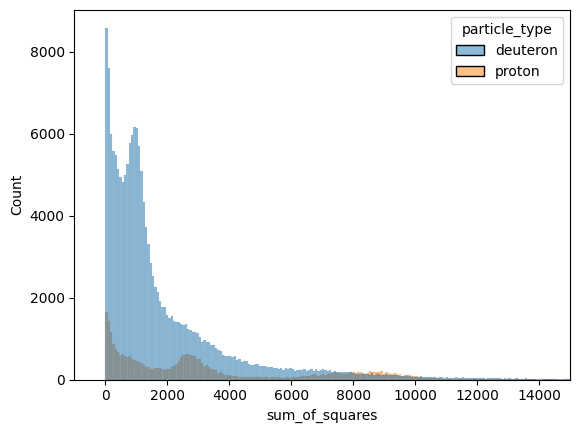

In [59]:
sns.histplot(data=allclusters, x='sum_of_squares', hue='particle_type')
plt.xlim(-1000, 15000)
plt.show()

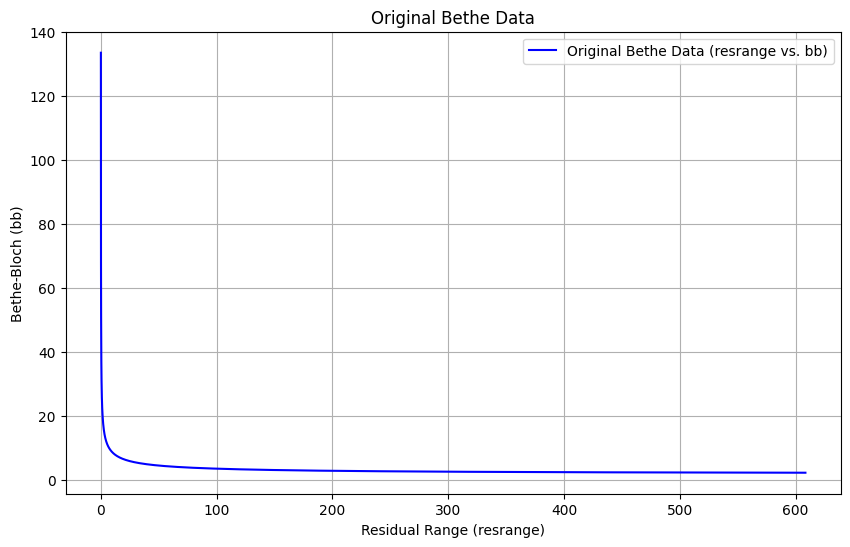

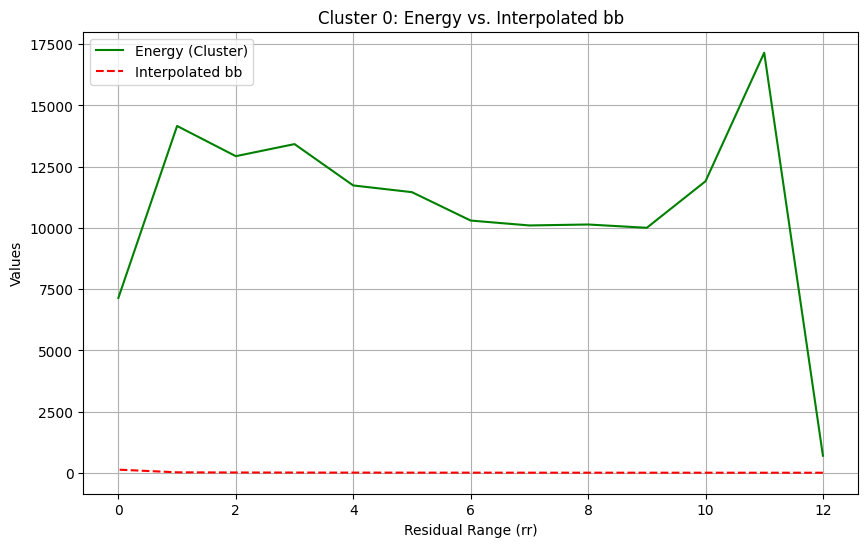

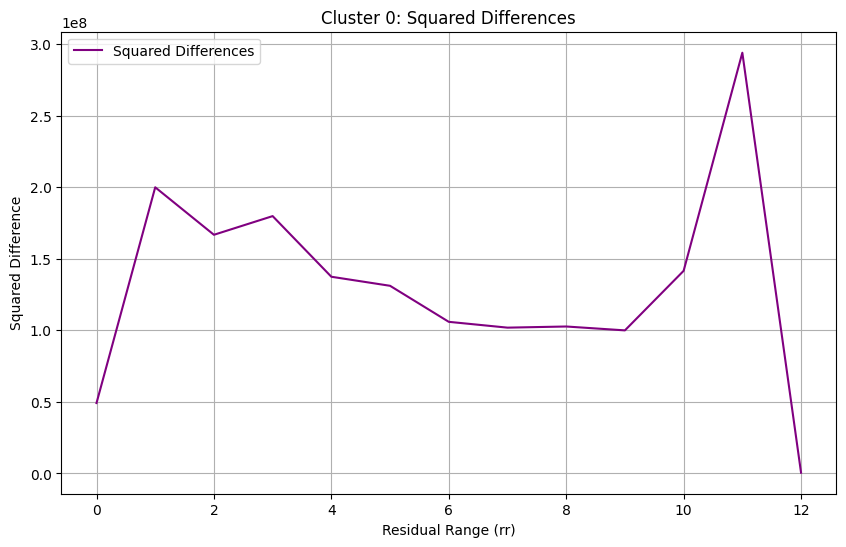

In [49]:
import matplotlib.pyplot as plt

# Plot 1: Original resrange vs. bb
plt.figure(figsize=(10, 6))
plt.plot(resrange, bb, label='Original Bethe Data (resrange vs. bb)', color='blue')
plt.xlabel('Residual Range (resrange)')
plt.ylabel('Bethe-Bloch (bb)')
plt.title('Original Bethe Data')
plt.legend()
plt.grid()
plt.show()

# Plot 2: Interpolated bb vs. rr for a specific cluster
cluster_idx = 0  # Change this index to visualize a different cluster
rr = all['rr'].iloc[cluster_idx]
energy = all['energy'].iloc[cluster_idx]
interpolated_bb = interpolator(rr)

plt.figure(figsize=(10, 6))
plt.plot(rr, energy, label='Energy (Cluster)', color='green')
plt.plot(rr, interpolated_bb, label='Interpolated bb', color='red', linestyle='--')
plt.xlabel('Residual Range (rr)')
plt.ylabel('Values')
plt.title(f'Cluster {cluster_idx}: Energy vs. Interpolated bb')
plt.legend()
plt.grid()
plt.show()

# Plot 3: Squared differences for the same cluster
squared_diff = (energy - interpolated_bb) ** 2

plt.figure(figsize=(10, 6))
plt.plot(rr, squared_diff, label='Squared Differences', color='purple')
plt.xlabel('Residual Range (rr)')
plt.ylabel('Squared Difference')
plt.title(f'Cluster {cluster_idx}: Squared Differences')
plt.legend()
plt.grid()
plt.show()